### Twin Axes (Multiple Scales on One Plot)
Used when **two metrics share the same x-axis but different scales.**

In [1]:
import matplotlib.pyplot as plt
import numpy as np

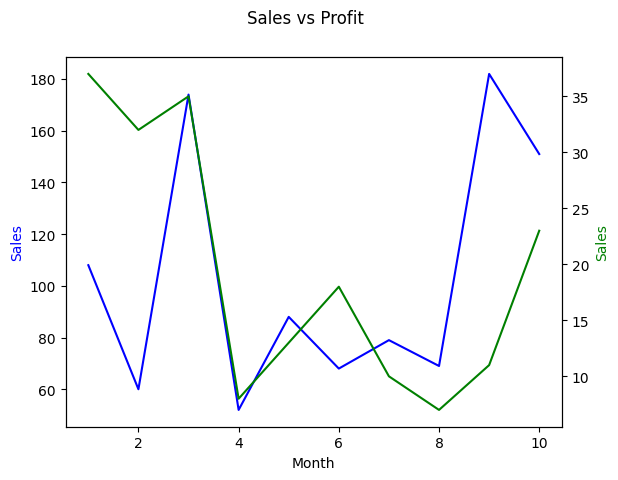

In [4]:
x = np.arange(1, 11)
sales = np.random.randint(50, 200, size=10)
profit = np.random.randint(5, 50, size=10)

fig, ax1 = plt.subplots()

ax1.plot(x, sales, color="blue", label="Sales")
ax1.set_ylabel("Sales", color="blue")

ax2 = ax1.twinx()
ax2.plot(x, profit, color="green", label="Profit")
ax2.set_ylabel("Sales", color="green")

ax1.set_xlabel("Month")
fig.suptitle("Sales vs Profit")

plt.show()

### Log Scales 
Used when values span **multiple orders of magnitude.**

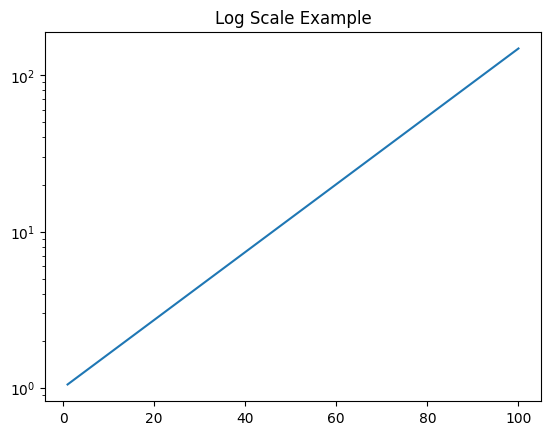

In [7]:
x = np.linspace(1, 100, 100)
y = np.exp(x / 20)

fig, ax = plt.subplots()
ax.plot(x, y)

ax.set_yscale("log")
ax.set_title("Log Scale Example")

plt.show()

Scale options:
- `linear`
- `log`
- `symlog`
- `logit`

### Colormaps (Information Encoding)
#### Continuous Colormap

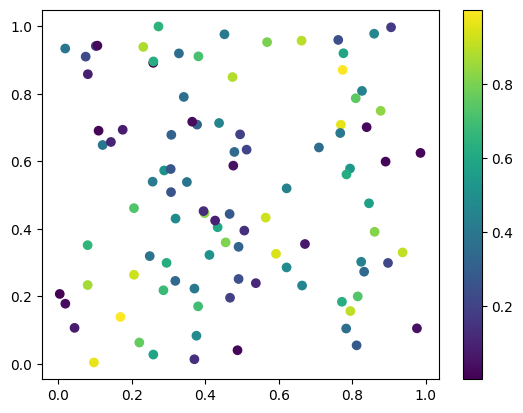

In [11]:
x = np.random.rand(100)
y = np.random.rand(100)
colors = np.random.rand(100)

fig, ax = plt.subplots()
sc = ax.scatter(x, y, c=colors, cmap="viridis")
plt.colorbar(sc)
plt.show()

### Error Bars (Uncertainty Visualization)

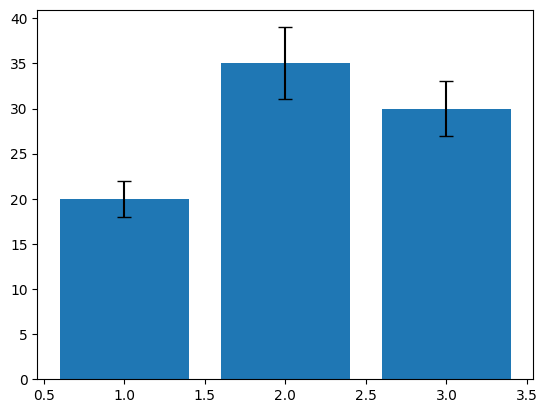

In [14]:
means = [20, 35, 30]
errors = [2, 4, 3]

fig, ax = plt.subplots()
ax.bar([1, 2, 3], means, yerr=errors, capsize=5)
plt.show()

### Area & Stack Plots
#### Area Plot

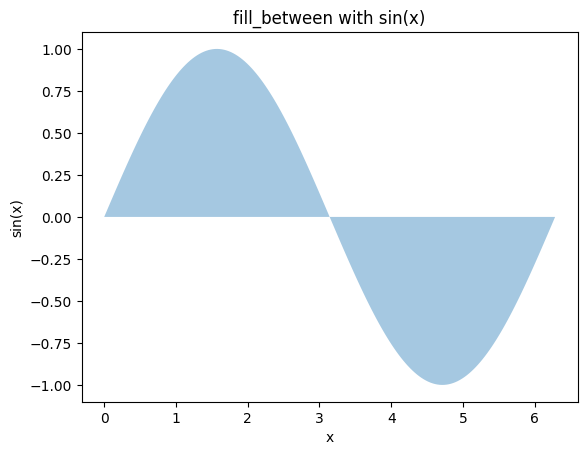

In [17]:
x = np.linspace(0, 2*np.pi, 200)

fig, ax = plt.subplots()
ax.fill_between(x, np.sin(x), alpha=0.4)
ax.set_title("fill_between with sin(x)")
ax.set_xlabel("x")
ax.set_ylabel("sin(x)")

plt.show()

#### Stack Plot

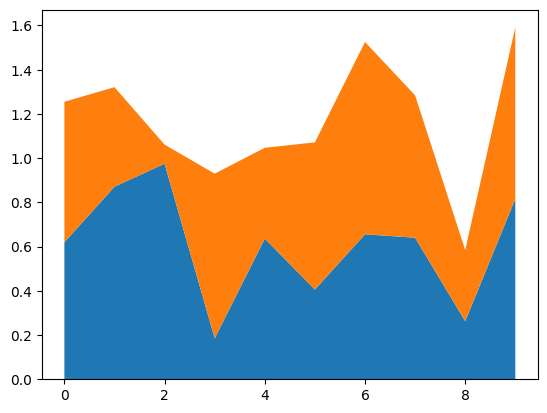

In [18]:
y1 = np.random.rand(10)
y2 = np.random.rand(10)

fig, ax = plt.subplots()
ax.stackplot(range(10), y1, y2)
plt.show()

### Time-Series Plotting

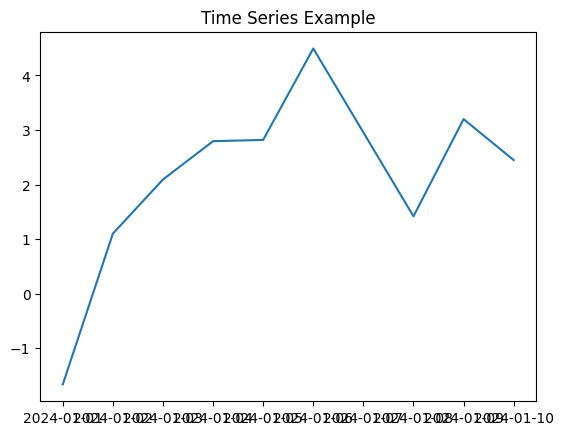

In [22]:
import pandas as pd

dates = pd.date_range("2024-01-01", periods=10)
values = np.random.randn(10).cumsum()

fig, ax = plt.subplots()
ax.plot(dates, values)
ax.set_title("Time Series Example")
plt.show()

### Custom Legends (Advanced Control)

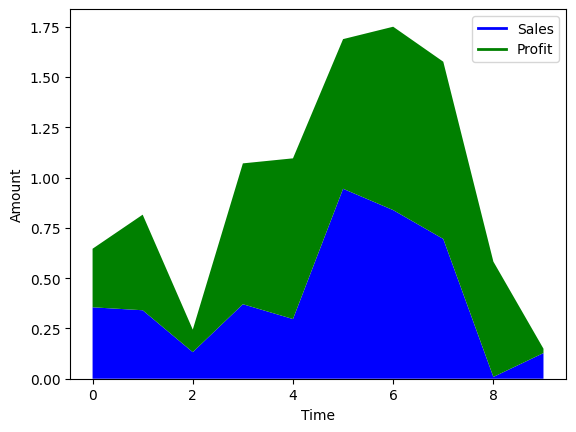

In [24]:
from matplotlib.lines import Line2D

y1 = np.random.rand(10)
y2 = np.random.rand(10)
x = range(10)

fig, ax = plt.subplots()
ax.stackplot(x, y1, y2, colors=["blue", "green"])

custom_lines = [
    Line2D([0], [0], color="blue", lw=2),
    Line2D([0], [0], color="green", lw=2)
]

ax.legend(custom_lines, ["Sales", "Profit"])

ax.set_xlabel("Time")
ax.set_ylabel("Amount")

plt.show()

### Downsampling

**Downsampling** reduces the *number of data points* in a dataset.
- Input: many points (high resolution)
- Output: fewer points (lower resolution)
- Goal: **performance + clarity**

#### Why it’s used
- Faster rendering
- Lower memory usage
- Less visual clutter
- Often necessary for interactive plots (zooming/panning)

#### Common downsampling methods
- **Decimation:** keep every nth point
- **Averaging / binning:** average points within bins
- **Min–max (envelope):** keep extremes per pixel column (preserves spikes)
- **LOD (Level of Detail):** dynamically change resolution when zooming

In [26]:
import numpy as np

# Original high-resolution data
x = np.linspace(0, 100, 1_000_000)
y = np.sin(x)

# Downsample: keep every 1000th point
x_ds = x[::1000]
y_ds = y[::1000]

print(len(x), "->", len(x_ds))

1000000 -> 1000


In [27]:
# Min–max downsampling per bin
bins = 1000
y_ds = [
    (y[i:i+bins].min(), y[i:i+bins].max())
    for i in range(0, len(y), bins)
]

### Rasterization

Rasterization converts graphical objects into a pixel-based image.
- Input: vectors (lines, curves, polygons)
- Output: pixels (bitmap)
- Goal: **fast drawing**

#### Why it’s used
- GPUs and screens work with pixels
- Faster rendering of complex scenes
- Predictable display cost

#### In plotting libraries
- Lines, text, markers are *vector objects*
- Rasterization decides **which pixels to color**

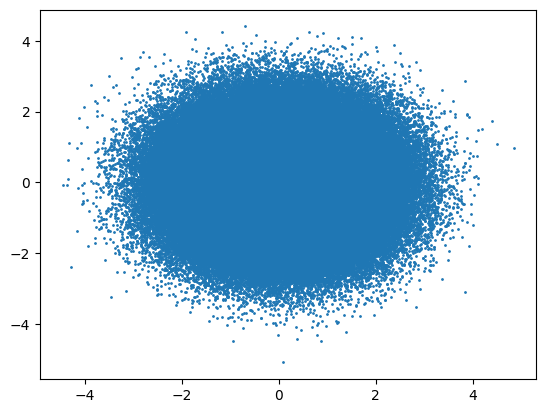

In [28]:
x = np.random.randn(500_000)
y = np.random.randn(500_000)

plt.scatter(x, y, s=1, rasterized=True)
plt.show()

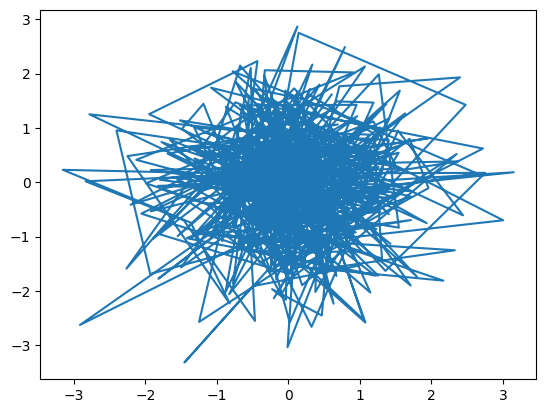

In [29]:
# Step 1: Downsample the data
x_ds = x[::1000]
y_ds = y[::1000]

# Step 2: Rasterize the plot
plt.plot(x_ds, y_ds, rasterized=True)
plt.show()